# Краткое описание
Первый этап пайплайна. Загружает data.xls, чистит данные (дубликаты, rule-based правки EDUCATION/MARRIAGE), делает EDA, генерирует 28 новых фич (utilization, payment_ratio, delay_trend, max_delay и др.), делит на train/test 80/20 со стратификацией, проводит adversarial validation (AUC=0.51), считает Mutual Information и сохраняет артефакты в artifacts/: train_processed.parquet, test_processed.parquet, cat_features.json, preprocessing_artifacts.pkl, summary.json.
1) Датасет: data.xls, 30 000 строк, 25 колонок;

2) Целевая переменная: default payment next month → default;

3) дисбаланс классов примерно 78/22;

4) train/test = 80/20 со стратификацией;

# Импорт Библиотек
Загружаем все зависимости пайплайна: pandas/numpy для данных, sklearn для split и Mutual Information, CatBoost для adversarial validation, matplotlib/seaborn для EDA. Фиксируем RANDOM_STATE=42 для воспроизводимости.

In [1]:
import os
import json
import pickle
import warnings
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedShuffleSplit, train_test_split, StratifiedKFold
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)
sns.set_style('whitegrid')

# ЗАГРУЗКА
Читаем data.xls, удаляем бесполезный ID, переименовываем target в default. Проверяем, что target на месте, и смотрим баланс классов.

In [2]:
DATA_PATH = Path('data.xls')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Нет файла: {DATA_PATH.resolve()}\n"
        f"В папке: {[p.name for p in Path('.').iterdir()]}"
    )

if DATA_PATH.suffix.lower() == '.xls':
    df = pd.read_excel(DATA_PATH, engine='xlrd', header=1)
elif DATA_PATH.suffix.lower() == '.xlsx':
    df = pd.read_excel(DATA_PATH, engine='openpyxl', header=1)
elif DATA_PATH.suffix.lower() == '.csv':
    df = pd.read_csv(DATA_PATH, header=1)
else:
    raise ValueError(f"Неизвестное расширение: {DATA_PATH.suffix}")

print(f"Загружено: {df.shape}")
print(f"Колонки: {df.columns.tolist()}\n")

if 'ID' in df.columns:
    df = df.drop(columns=['ID'])
df = df.rename(columns={'default payment next month': 'default'})

assert 'default' in df.columns, f"Нет 'default'. Колонки: {df.columns.tolist()}"
print(f"После rename/drop ID: {df.shape}")
print(df['default'].value_counts())

Загружено: (30000, 25)
Колонки: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

После rename/drop ID: (30000, 24)
default
0    23364
1     6636
Name: count, dtype: int64


# ПРОПУСКИ / ДУБЛИКАТЫ
Проверяем пропуски и удаляем полные дубликаты строк, чтобы они не искажали распределение и не создавали утечку.

In [3]:
print("\n--- Пропуски ---")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing if len(missing) else "  Пропусков нет")

n_dups = df.duplicated().sum()
print(f"\nПолных дубликатов строк: {n_dups}")
if n_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Удалено дубликатов: {n_dups}, новая форма: {df.shape}")


--- Пропуски ---
  Пропусков нет

Полных дубликатов строк: 35
Удалено дубликатов: 35, новая форма: (29965, 24)


# РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ
Смотрим баланс классов (77.87% / 22.13%) и считаем imbalance ratio. Это определяет выбор стратификации и метрик.


--- Распределение целевой ---
default
0    23335
1     6630
Name: count, dtype: int64
default
0    77.87 %
1    22.13 %
Name: count, dtype: str
Imbalance ratio: 3.52 : 1


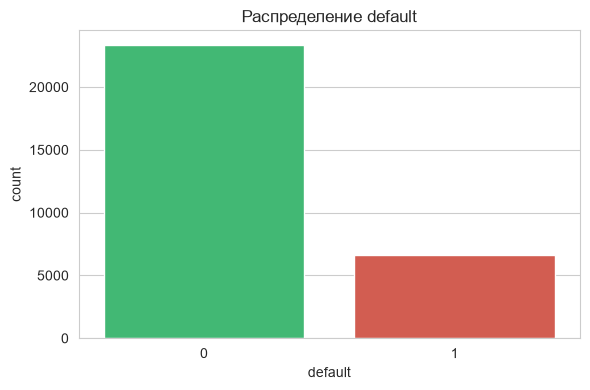

In [4]:
counts = df['default'].value_counts()
print("\n--- Распределение целевой ---")
print(counts)
print((counts / len(df) * 100).round(2).astype(str) + ' %')
print(f"Imbalance ratio: {counts[0] / counts[1]:.2f} : 1")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='default', palette=['#2ecc71', '#e74c3c'])
plt.title('Распределение default')
plt.tight_layout()
plt.show()

Дисбаланс не критический (не 1:100, как в fraud detection), но достаточный, чтобы:

1) использовать StratifiedShuffleSplit - иначе баланс в train/test может «поплыть»;

1) при обучении моделей подумать про class_weight='balanced' или scale_pos_weight;

1) использовать метрики, устойчивые к дисбалансу (ROC-AUC, PR-AUC, F1).



# ОБЗОР ЧИСЛОВЫХ
Смотрим статистики и распределения LIMIT_BAL, AGE, BILL_AMT*, PAY_AMT*. Выявляем выбросы, скошенность и отрицательные BILL_AMT (переплата/кредит).


--- Статистики LIMIT_BAL / AGE ---
        LIMIT_BAL       AGE
count    29965.00  29965.00
mean    167442.01     35.49
std     129760.14      9.22
min      10000.00     21.00
25%      50000.00     28.00
50%     140000.00     34.00
75%     240000.00     41.00
max    1000000.00     79.00

--- Статистики BILL_AMT ---
       BILL_AMT1  BILL_AMT2   BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
count   29965.00   29965.00    29965.00   29965.00   29965.00   29965.00
mean    51283.01   49236.37    47067.92   43313.33   40358.33   38917.01
std     73658.13   71195.57    69371.35   64353.51   60817.13   59574.15
min   -165580.00  -69777.00  -157264.00 -170000.00  -81334.00 -339603.00
25%      3595.00    3010.00     2711.00    2360.00    1787.00    1262.00
50%     22438.00   21295.00    20135.00   19081.00   18130.00   17124.00
75%     67260.00   64109.00    60201.00   54601.00   50247.00   49252.00
max    964511.00  983931.00  1664089.00  891586.00  927171.00  961664.00

--- Статистики PAY_AMT --

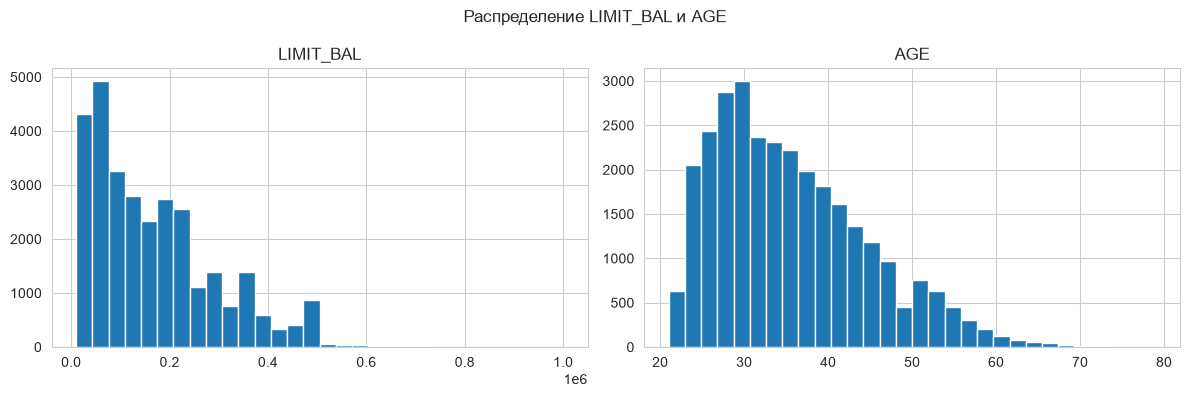

In [5]:
bill_cols       = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols    = [f'PAY_AMT{i}'  for i in range(1, 7)]
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("\n--- Статистики LIMIT_BAL / AGE ---")
print(df[['LIMIT_BAL', 'AGE']].describe().round(2))
print("\n--- Статистики BILL_AMT ---")
print(df[bill_cols].describe().round(2))
print("\n--- Статистики PAY_AMT ---")
print(df[pay_amt_cols].describe().round(2))

df[['LIMIT_BAL', 'AGE']].hist(bins=30, figsize=(12, 4))
plt.suptitle('Распределение LIMIT_BAL и AGE')
plt.tight_layout()
plt.show()

LIMIT_BAL: mean 167k, std 130k, range 10k–1M → огромный разброс.

AGE: mean 35.5, std 9.2, range 21–79 → нормальное распределение, без выбросов.

BILL_AMT: минимумы отрицательные (до -339 603).

PAY_AMT: min 0, max 1 684 259 → длинный правый хвост, много нулей.

Что это значит:

LIMIT_BAL сильно скошен → для линейных моделей нужна нормализация/лог, для бустинга - не критично.

Отрицательные BILL_AMT (~13% значений) - это переплата или кредитный баланс (банк должен клиенту). Это важный сигнал платёжного поведения, не выброс и не ошибка. Мы его сохраним и даже добавим бинарный флаг.

PAY_AMT с длинным хвостом → логарифмирование или rank-преобразование может помочь линейным моделям, но для CatBoost/GBM - необязательно.

AGE распределён нормально → не требует преобразований.

# PAY_* - ОРДИНАЛЬНЫЕ
PAY_0..PAY_6 - это статус просрочки по месяцам (шкала от -2 до 8). Проверяем уникальные значения и распределения.


--- Значения PAY_* ---
PAY_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


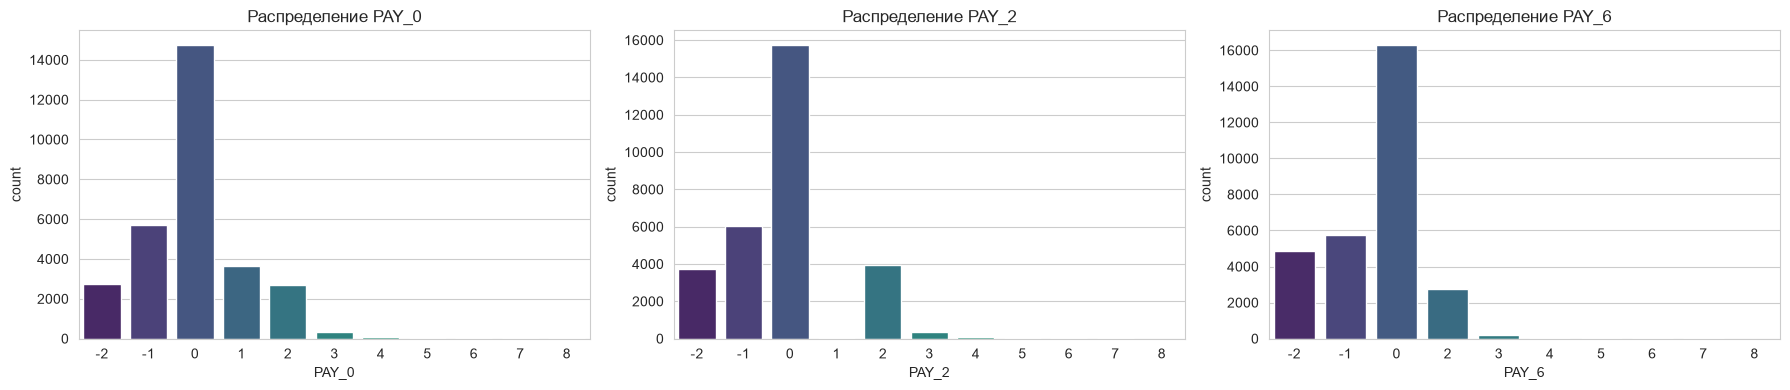

In [6]:
print("\n--- Значения PAY_* ---")
for col in pay_status_cols:
    print(f"{col}: {sorted(df[col].unique())}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['PAY_0', 'PAY_2', 'PAY_6']):
    sns.countplot(data=df, x=col, ax=ax, palette='viridis')
    ax.set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

Шкала ординальная: -2 = нет потребления кредита, -1 = оплачен полностью, 0 = revolving, 1..8 = месяцы просрочки.

Порядок значений важен → можно оставлять как числа (бустинг сам разберётся) или как категориальные с учётом порядка.

Отсутствие 1 в PAY_5, PAY_6 - это структурная особенность данных (в исходном датасете UCI она тоже есть). Не баг, не требует исправления.

Значения > 0 - прямой сигнал просрочки, их надо агрегировать в отдельные фичи.

# КАТЕГОРИАЛЬНЫЕ ПРОТИВ ЦЕЛЕВОЙ
Смотрим default rate в разрезе SEX, EDUCATION, MARRIAGE. Находим «мусорные» категории (EDUCATION=0,5,6, MARRIAGE=0), которые нужно почистить.

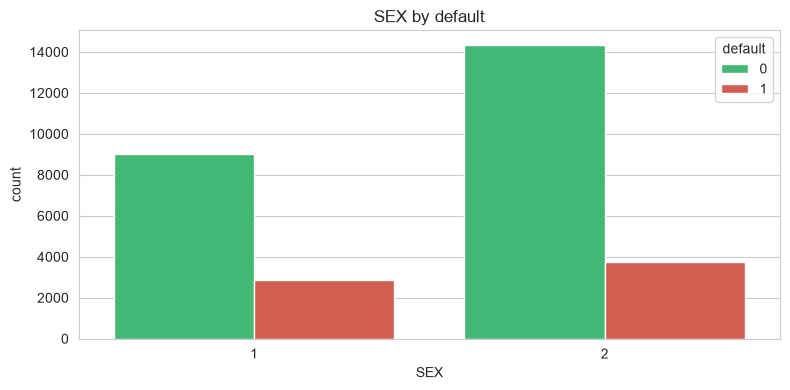

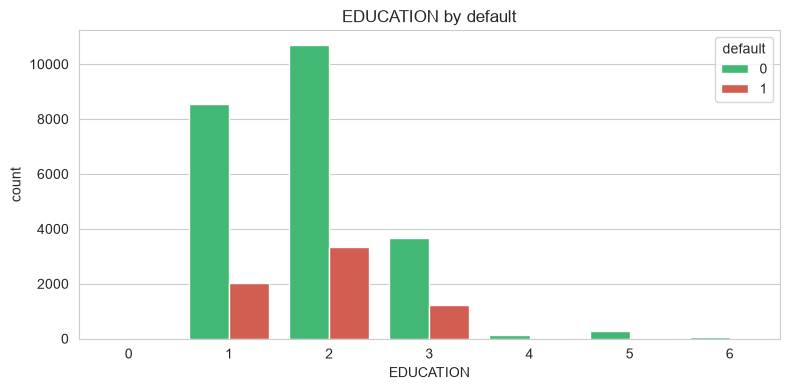

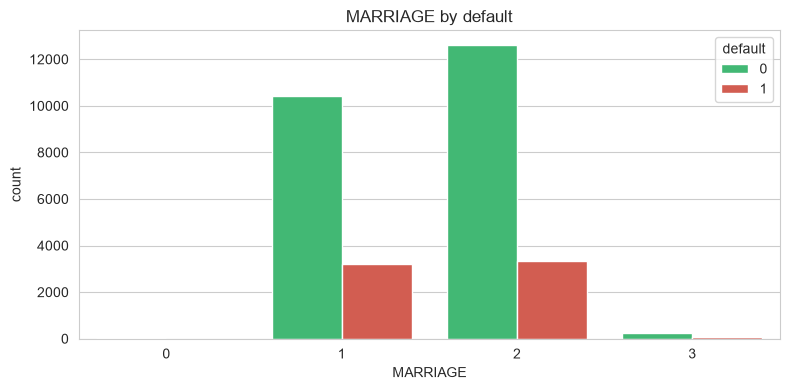

In [7]:
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='default', palette=['#2ecc71', '#e74c3c'])
    plt.title(f'{col} by default')
    plt.tight_layout()
    plt.show()

Мы видим default rate по каждой категории.

В EDUCATION и MARRIAGE есть недокументированные коды (0, 5, 6 и 0 соответственно) - их надо смапить.

SEX - всего 2 категории, дисбаланс небольшой, признак слабый, но иногда полезный во взаимодействиях.

Категории с очень низким default rate и малой частотой можно в будущем агрегировать («other»).

# BOXPLOTS КЛЮЧЕВЫХ ФИЧЕЙ
Сравниваем распределения ключевых фичей между классами. Видим, что PAY_0 и PAY_AMT1 хорошо разделяют классы, а AGE - почти нет.

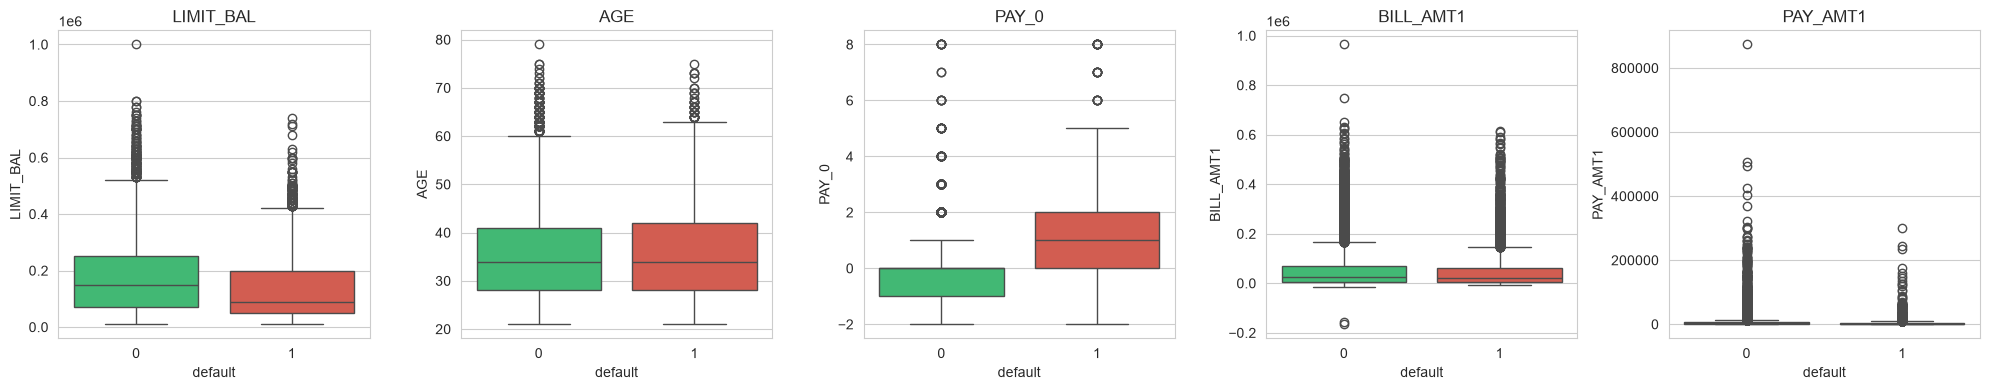


Средние по классам:
         LIMIT_BAL    AGE  PAY_0  BILL_AMT1  PAY_AMT1
default                                              
0        178084.51  35.42  -0.21   52058.72   6315.05
1        129984.57  35.72   0.67   48552.81   3400.12


In [8]:
key_features = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(1, len(key_features), figsize=(20, 4))
for ax, col in zip(axes, key_features):
    sns.boxplot(data=df, x='default', y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{col}')
plt.tight_layout()
plt.show()

print("\nСредние по классам:")
print(df.groupby('default')[key_features].mean().round(2))

LIMIT_BAL: у дефолтных средний лимит ниже → банки уже «отсеивают» риск через лимит. Сильный сигнал.

AGE: почти идентичен → возраст сам по себе плохо разделяет классы, слабый признак в чистом виде.

PAY_0: у дефолтных в среднем +0.67 (просрочка), у non-default -0.21 (нет просрочки). Самый сильный сигнал.

BILL_AMT1: почти одинаковый → сам по себе долг не отличает дефолтных, важнее отношение долга к лимиту (это мы создадим в FE).

PAY_AMT1: дефолтные платят почти в 2 раза меньше → платёжная дисциплина критична.

# КОРРЕЛЯЦИИ
Heatmap + топ-15 корреляций с target + поиск пар |corr| > 0.95. Находим мультиколлинеарность (BILL_AMT1 ↔ BILL_AMT2 = 0.951) и самые сильные линейные сигналы.

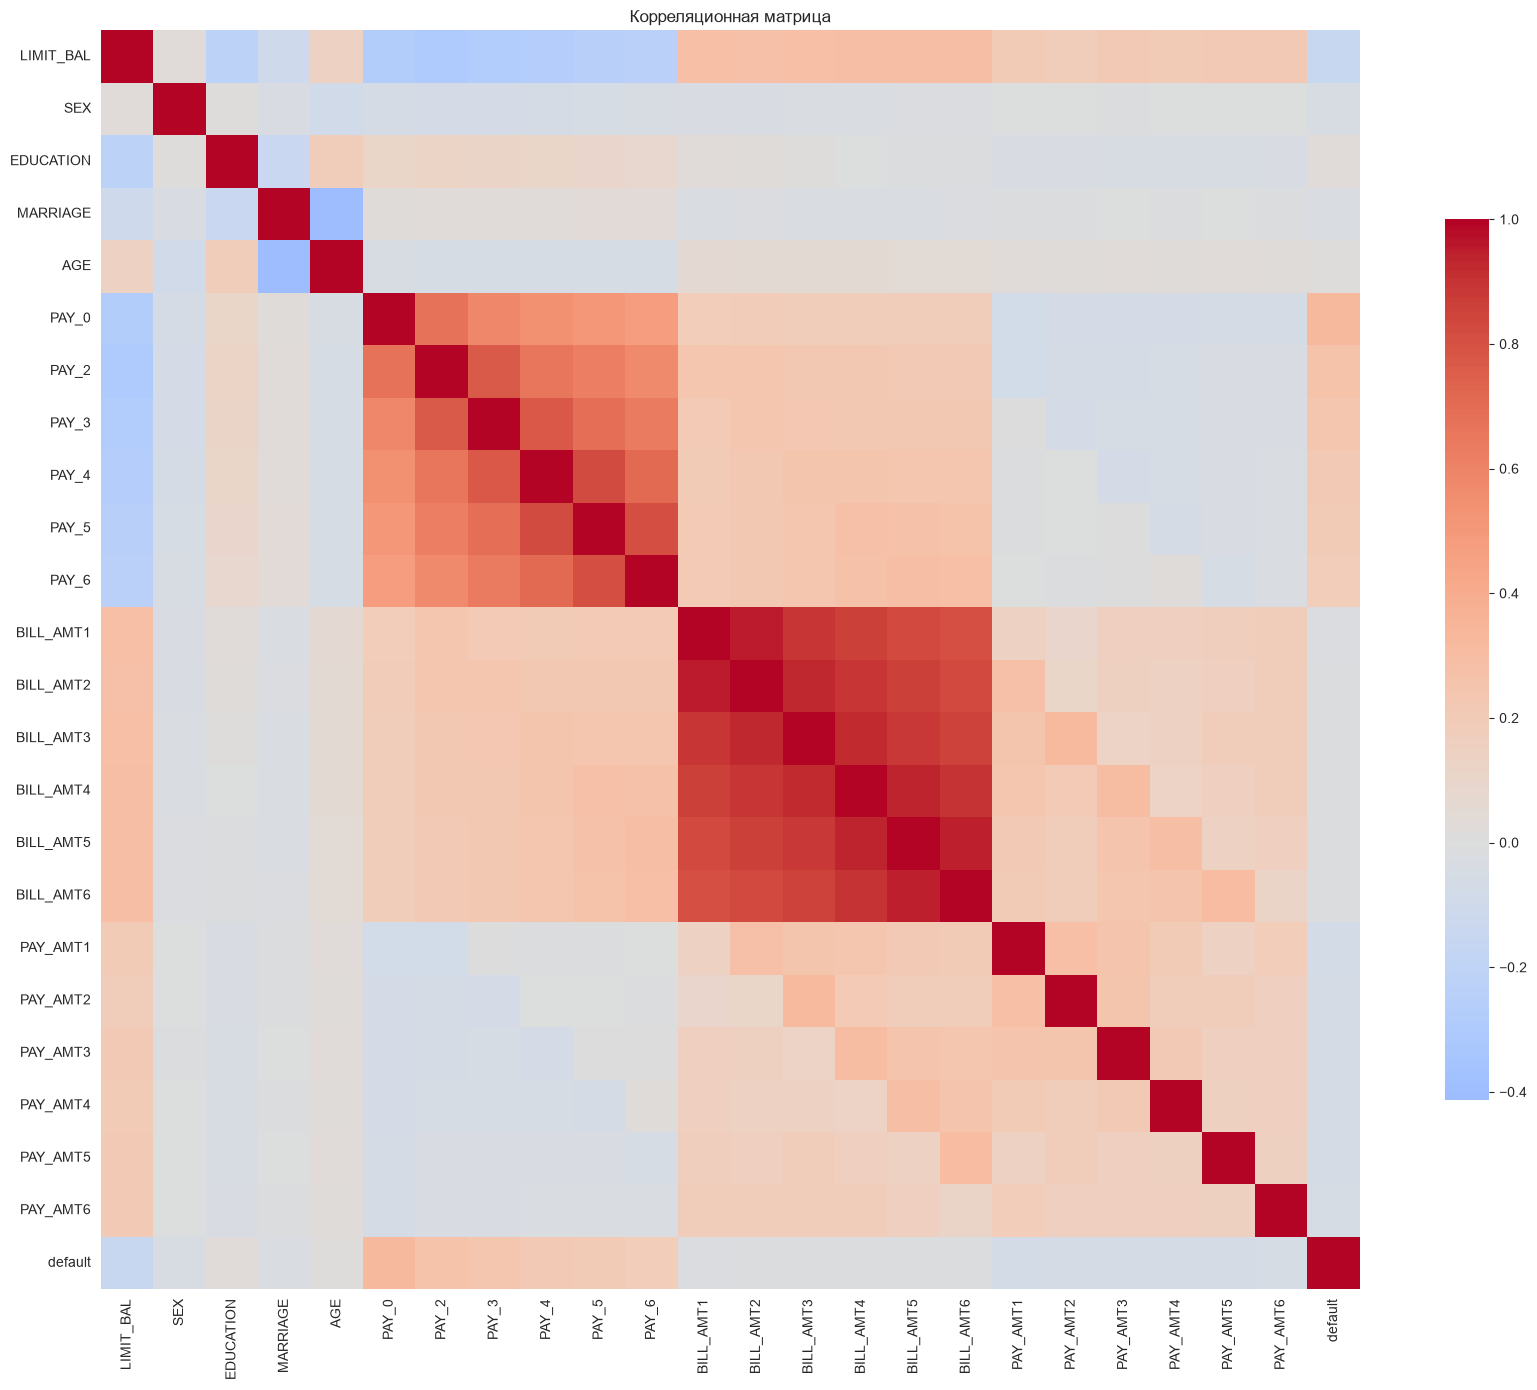


Топ-15 корреляций с target (по |corr|):
PAY_0        0.3250
PAY_2        0.2637
PAY_3        0.2352
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1867
LIMIT_BAL   -0.1539
PAY_AMT1    -0.0730
PAY_AMT2    -0.0586
PAY_AMT4    -0.0569
PAY_AMT3    -0.0563
PAY_AMT5    -0.0552
PAY_AMT6    -0.0533
SEX         -0.0397
EDUCATION    0.0280
Name: default, dtype: float64

Пар с |corr| > 0.95: 1
  BILL_AMT1 ↔ BILL_AMT2: 0.951


In [9]:
plt.figure(figsize=(18, 14))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.7})
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

target_corr = corr['default'].drop('default').sort_values(key=abs, ascending=False)
print("\nТоп-15 корреляций с target (по |corr|):")
print(target_corr.head(15).round(4))

# Мультиколлинеарность: пары |corr| > 0.95
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(c, r, upper.loc[r, c])
             for c in upper.columns for r in upper.index
             if pd.notna(upper.loc[r, c]) and upper.loc[r, c] > 0.95]
print(f"\nПар с |corr| > 0.95: {len(high_corr)}")
for c, r, v in high_corr[:20]:
    print(f"  {r} ↔ {c}: {v:.3f}")

Просрочки доминируют: чем больше месяцев с просрочкой → тем выше риск. Логично: история просрочек - лучший предиктор будущего дефолта.

Корреляции умеренные (макс 0.33) - это нормально: линейная связь слабая, но нелинейная (через MI) будет намного сильнее. Это аргумент в пользу бустинга, а не логистической регрессии.

BILL_AMT сильно коррелированы между собой → в линейных моделях оставить один или использовать PCA; для бустинга - не критично, но можно оставить avg_bill как агрегат.

SEX и EDUCATION слабые → возможно, их стоит оставить только для взаимодействий.

# ОЧИСТКА RULE-BASED
Приводим категории к документированным: EDUCATION 0/5/6 → 4, MARRIAGE 0 → 3. Отрицательные BILL_AMT оставляем - это сигнал, а не ошибка.

In [10]:
df = df.copy()

df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0: 3})

print("\nПосле очистки:")
print(f"  EDUCATION: {sorted(df['EDUCATION'].unique())}")
print(f"  MARRIAGE:  {sorted(df['MARRIAGE'].unique())}")
print(f"  SEX:       {sorted(df['SEX'].unique())}")
print(f"  BILL_AMT < 0: {(df[bill_cols] < 0).sum().sum()}")
print(f"  AGE < 18:     {(df['AGE'] < 18).sum()}  AGE > 100: {(df['AGE'] > 100).sum()}")


После очистки:
  EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  MARRIAGE:  [np.int64(1), np.int64(2), np.int64(3)]
  SEX:       [np.int64(1), np.int64(2)]
  BILL_AMT < 0: 3932
  AGE < 18:     0  AGE > 100: 0


# FEATURE ENGINEERING
Создаём 28 новых фичей: агрегаты за 6 месяцев (avg/std/sum), отношения (utilization, payment_ratio), тренды (bill_trend, delay_trend), статистики просрочек (max_delay, months_with_debt), взаимодействия и лог-признаки. Обрабатываем inf и NaN.

In [11]:
def add_features(df):
    df = df.copy()
    eps = 1

    # Средние / std за 6 месяцев
    df['avg_bill']    = df[bill_cols].mean(axis=1)
    df['avg_payment'] = df[pay_amt_cols].mean(axis=1)
    df['std_bill']    = df[bill_cols].std(axis=1)
    df['std_payment'] = df[pay_amt_cols].std(axis=1)

    # Суммы
    df['total_bill']    = df[bill_cols].sum(axis=1)
    df['total_payment'] = df[pay_amt_cols].sum(axis=1)
    df['total_debt']    = df['total_bill'] - df['total_payment']

    # Отношения
    df['utilization']      = df['BILL_AMT1']   / (df['LIMIT_BAL'] + eps)
    df['avg_utilization']  = df['avg_bill']    / (df['LIMIT_BAL'] + eps)
    df['payment_ratio']    = df['avg_payment'] / (df['avg_bill'] + eps)
    df['payment_to_limit'] = df['avg_payment'] / (df['LIMIT_BAL'] + eps)
    df['limit_per_age']    = df['LIMIT_BAL']   / (df['AGE'] + eps)
    df['payment_ratio_1']  = df['PAY_AMT1']    / (df['BILL_AMT1'] + eps)

    # Тренды
    df['bill_trend']    = df['BILL_AMT1'] - df['BILL_AMT6']
    df['payment_trend'] = df['PAY_AMT1']  - df['PAY_AMT6']
    df['delay_trend']   = df['PAY_0']     - df['PAY_6']

    # Просрочки
    df['max_delay']         = df[pay_status_cols].max(axis=1)
    df['min_delay']         = df[pay_status_cols].min(axis=1)
    df['mean_delay']        = df[pay_status_cols].mean(axis=1)
    df['months_with_debt']  = (df[pay_status_cols] > 0).sum(axis=1)
    df['months_fully_paid'] = (df[pay_status_cols] == -1).sum(axis=1)
    df['sum_positive_delay'] = df[pay_status_cols].clip(lower=0).sum(axis=1)

    # Отрицательный счёт (переплата / кредит)
    df['has_negative_bill'] = (df[bill_cols] < 0).any(axis=1).astype(int)

    # Взаимодействия
    df['bill_x_age'] = df['BILL_AMT1'] * df['AGE']
    df['pay_x_pay0'] = df['PAY_AMT1']  * df['PAY_0'].clip(lower=0)

    # Утилизация: изменение
    df['utilization_change'] = df['utilization'] - df['avg_utilization']

    # Лог-признаки для тяжёлых хвостов
    df['log_bill1'] = np.log1p(df['BILL_AMT1'].abs())
    df['log_pay1']  = np.log1p(df['PAY_AMT1'].abs())

    # Убираем inf
    ratio_cols = ['utilization', 'avg_utilization', 'payment_ratio',
                  'payment_to_limit', 'limit_per_age', 'payment_ratio_1',
                  'utilization_change']
    for c in ratio_cols:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan).fillna(0)

    return df


df = add_features(df)

new_features = [
    'avg_bill', 'avg_payment', 'std_bill', 'std_payment',
    'total_bill', 'total_payment', 'total_debt',
    'utilization', 'avg_utilization', 'payment_ratio',
    'payment_to_limit', 'limit_per_age', 'payment_ratio_1',
    'bill_trend', 'payment_trend', 'delay_trend',
    'max_delay', 'min_delay', 'mean_delay',
    'months_with_debt', 'months_fully_paid', 'sum_positive_delay',
    'has_negative_bill', 'bill_x_age', 'pay_x_pay0',
    'utilization_change', 'log_bill1', 'log_pay1',
]
print(f"\n FE завершён: {df.shape}, новых фичей: {len(new_features)}")


 FE завершён: (29965, 52), новых фичей: 28


# STRATIFIED SPLIT 
Делим данные на train/test 80/20 со стратификацией по target, чтобы сохранить пропорцию классов и получить честную отложенную выборку.

In [12]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(df, df['default']))

train = df.iloc[train_idx].copy().reset_index(drop=True)
test  = df.iloc[test_idx].copy().reset_index(drop=True)

print(f"\nTrain: {train.shape}, Test: {test.shape}")
print(f"Баланс train: {train['default'].value_counts(normalize=True).round(4).to_dict()}")
print(f"Баланс test:  {test['default'].value_counts(normalize=True).round(4).to_dict()}")


Train: (23972, 52), Test: (5993, 52)
Баланс train: {0: 0.7787, 1: 0.2213}
Баланс test:  {0: 0.7787, 1: 0.2213}


Стратификация сработала - распределение target в train и test совпадает с точностью до 4 знаков.

Test останется «нетронутым» до финальной оценки → честная оценка обобщения.

Объём test ~6 000 - достаточно для узких доверительных интервалов метрик.

# ADVERSAARIAL VALIDATION
Обучаем CatBoost различать train и test. Если AUC > 0.6 - распределения сдвинуты. У нас AUC = 0.51 → train и test похожи, можно доверять обычному split.

In [13]:
print("\n--- Adversarial validation (train vs test) ---")
adv_features = [c for c in train.columns if c != 'default']
adv_X = pd.concat([train[adv_features], test[adv_features]], axis=0, ignore_index=True)
adv_y = np.r_[np.zeros(len(train)), np.ones(len(test))]

adv_X_tr, adv_X_va, adv_y_tr, adv_y_va = train_test_split(
    adv_X, adv_y, test_size=0.3, stratify=adv_y, random_state=RANDOM_STATE
)
adv_model = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05,
    loss_function='Logloss', eval_metric='AUC',
    random_seed=RANDOM_STATE, verbose=0
)
adv_model.fit(adv_X_tr, adv_y_tr, eval_set=(adv_X_va, adv_y_va))
adv_auc = adv_model.best_score_['validation']['AUC']
print(f"Adversarial AUC = {adv_auc:.4f}  "
      f"({' Распределения сдвинуты' if adv_auc > 0.6 else ' train и test похожи'})")


--- Adversarial validation (train vs test) ---
Adversarial AUC = 0.5076  ( train и test похожи)


Модель не может отличить train от test → распределения идентичны.

Это значит: можно доверять обычному случайному split.

Если бы AUC был >0.6, то train и test пришли бы из разных источников/периодов, и потребовалась бы схема с time-based или weighted validation.

Для кредитного скоринга это отличный результат: данные однородны, и модель, обученная на train, будет валидно работать на test.

# ВАЛИДАЦИОННЫЙ SPLIT ВНУТРИ TRAIN
Выделяем внутреннюю валидацию (80/20 со стратификацией) для подбора гиперпараметров, чтобы не трогать test до финальной оценки.

In [14]:
X_full = train.drop(columns='default')
y_full = train['default']

X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE
)
print(f"\nTrain-inner: {X_tr.shape}, Val-inner: {X_val.shape}")
print(f"Balans y_tr: {y_tr.value_counts(normalize=True).round(4).to_dict()}")


Train-inner: (19177, 51), Val-inner: (4795, 51)
Balans y_tr: {0: 0.7787, 1: 0.2213}


Есть три уровня данных: train-inner / val-inner / test.

На train-inner обучаем модели, на val-inner подбираем гиперпараметры, на test - финальная оценка.

Это защищает от overfitting к test: если подбирать гиперпараметры на test, метрики будут завышены и не воспроизведутся в проде.

# АРТЕФАКТЫ (только на train)
Собираем всё нужное для inference: cat_features, списки колонок, медианы и моды (только по train - чтобы не было утечки), target mapping, параметры split.

In [15]:
artifacts = {}
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE']
artifacts['cat_features']    = cat_features
artifacts['bill_cols']       = bill_cols
artifacts['pay_amt_cols']    = pay_amt_cols
artifacts['pay_status_cols'] = pay_status_cols
artifacts['new_features']    = new_features

numeric_for_median = [c for c in train.columns if c not in cat_features + ['default']]
artifacts['numeric_medians'] = train[numeric_for_median].median().to_dict()
artifacts['cat_modes']       = {c: train[c].mode().iloc[0] for c in cat_features}

artifacts['target_mapping'] = {0: 0, 1: 1}
artifacts['random_state']   = RANDOM_STATE
artifacts['test_size']      = 0.2
artifacts['split_type']     = 'StratifiedShuffleSplit'

print(f"\n Артефакты собраны: cat_features={cat_features}, "
      f"медиан={len(artifacts['numeric_medians'])}")


 Артефакты собраны: cat_features=['SEX', 'EDUCATION', 'MARRIAGE'], медиан=48


# ИМПУТАЦИЯ
Заполняем числовые признаки медианами, категориальные - модами, используя статистики из train. Приводим категориальные к int. Проверяем, что пропусков не осталось. Приведение типов важно для CatBoost: cat_features должны быть int, а не float или object.

In [16]:
def apply_imputation(frame, artifacts):
    f = frame.copy()
    for col, med in artifacts['numeric_medians'].items():
        if col in f.columns:
            f[col] = f[col].fillna(med)
    for col, mode in artifacts['cat_modes'].items():
        if col in f.columns:
            f[col] = f[col].fillna(mode)
    return f


train = apply_imputation(train, artifacts)
test  = apply_imputation(test,  artifacts)

for col in cat_features:
    train[col] = train[col].astype(int)
    test[col]  = test[col].astype(int)

print(f"Пропусков train: {train.isnull().sum().sum()}")
print(f"Пропусков test:  {test.isnull().sum().sum()}")

Пропусков train: 0
Пропусков test:  0


# MUTUAL INFORMATION
Считаем MI между признаками и target - это нелинейная альтернатива корреляции. Проверяем, полезны ли новые фичи. Топ: PAY_0, sum_positive_delay, months_with_debt, mean_delay, max_delay.

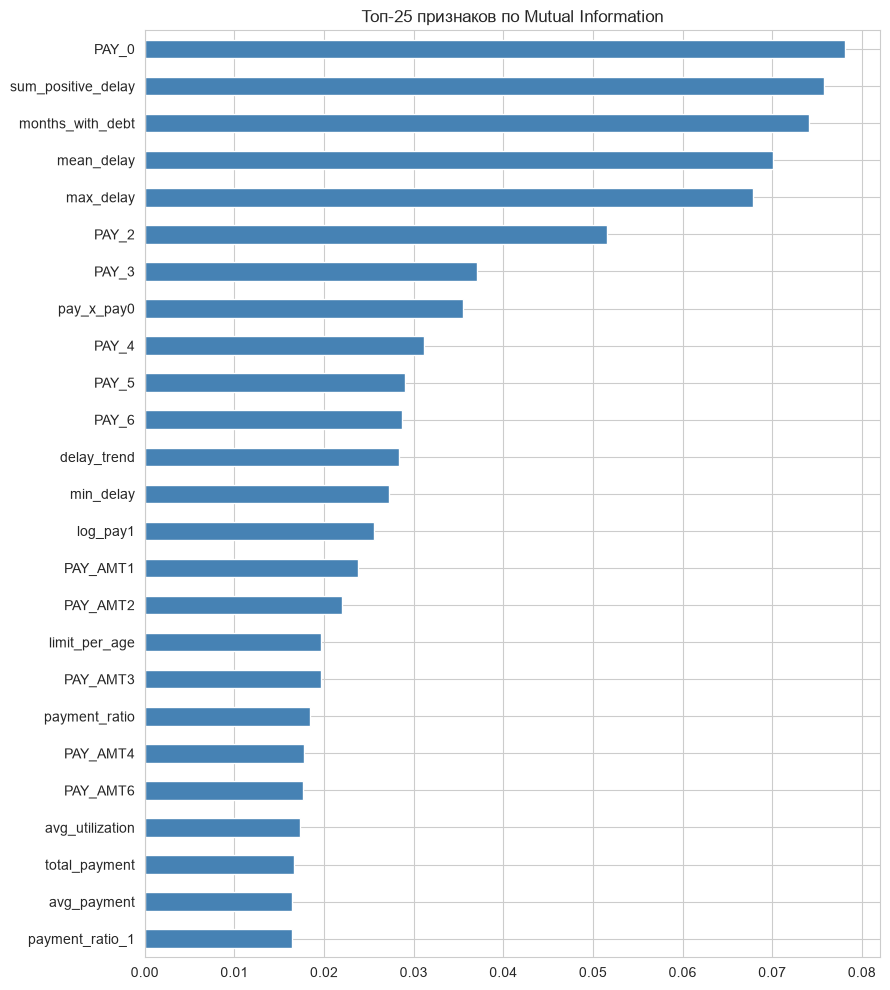


Топ-15 по MI:
PAY_0                 0.0781
sum_positive_delay    0.0758
months_with_debt      0.0741
mean_delay            0.0700
max_delay             0.0678
PAY_2                 0.0516
PAY_3                 0.0371
pay_x_pay0            0.0356
PAY_4                 0.0311
PAY_5                 0.0290
PAY_6                 0.0287
delay_trend           0.0283
min_delay             0.0272
log_pay1              0.0256
PAY_AMT1              0.0238
dtype: float64


In [17]:
train_mi = train.copy()
for col in cat_features:
    train_mi[col] = train_mi[col].astype('category').cat.codes

feature_cols = [c for c in train_mi.columns if c != 'default']
mi = mutual_info_classif(train_mi[feature_cols].fillna(0),
                         train_mi['default'],
                         discrete_features='auto',
                         random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 10))
mi_series.head(25).plot(kind='barh', color='steelblue')
plt.title('Топ-25 признаков по Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nТоп-15 по MI:")
print(mi_series.head(15).round(4))

PAY_0 - топ-1, подтверждает корреляционный анализ.

Engineered features работают: sum_positive_delay, months_with_debt, mean_delay, max_delay - все в топ-5 и опережают сырые PAY_2..PAY_6. Значит, агрегация истории просрочек дала модели новый сигнал, которого не было в сырых признаках.

pay_x_pay0 - взаимодействие суммы платежа и просрочки - в топ-10. Взаимодействия действительно полезны.

delay_trend (изменение просрочки во времени) - в топ-15 → динамика важна.

MI в 4 раза выше у топ-фичей, чем у SEX/EDUCATION → категориальные слабые, их роль - только в композициях.

# ПРОВЕРКА НОВЫХ ФИЧЕЙ
Boxplot новых признаков по классам + средние. Убеждаемся, что engineered features действительно различают дефолтных и недефолтных клиентов (например, payment_ratio ниже у дефолтных, max_delay - выше).

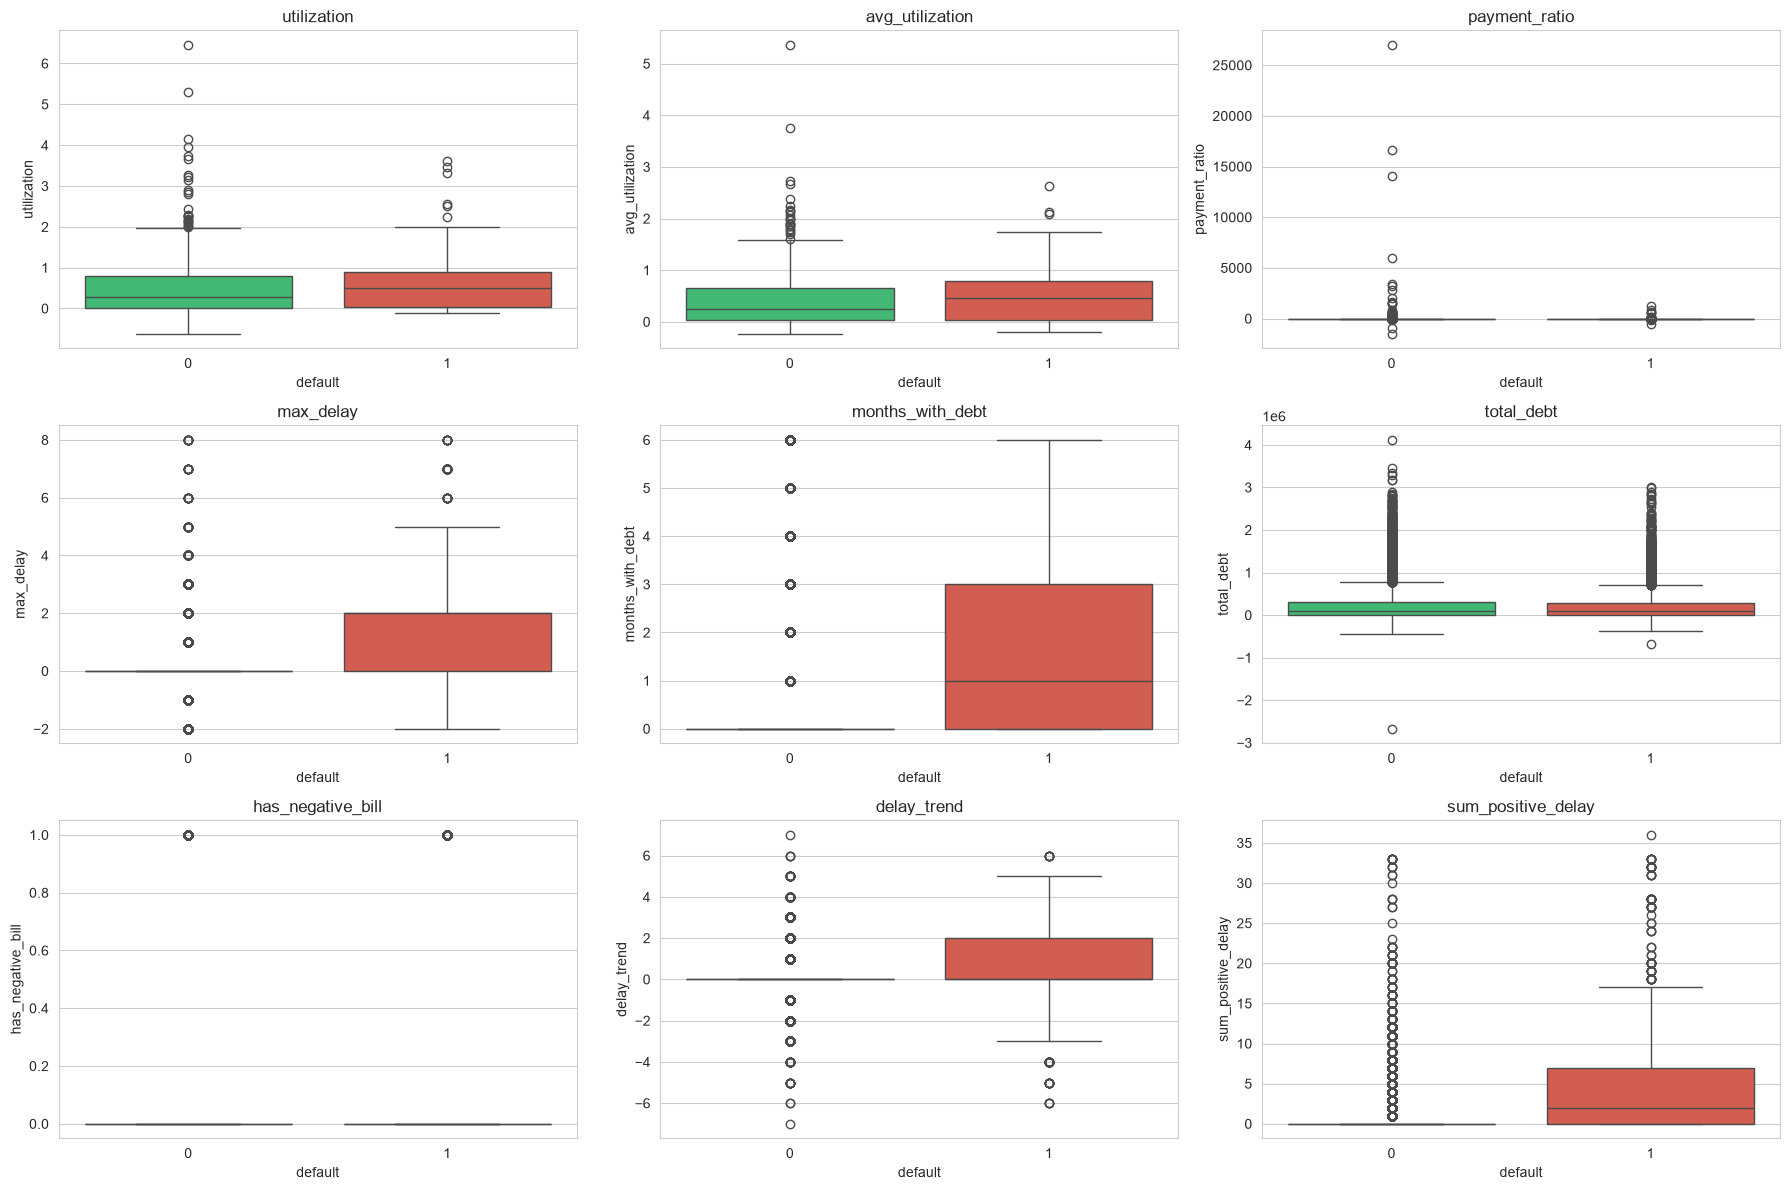


Средние новых фичей по классам:
         utilization  avg_utilization  payment_ratio  max_delay  months_with_debt  total_debt  has_negative_bill  delay_trend  sum_positive_delay
default                                                                                                                                          
0              0.408            0.354           5.18      0.202             0.503  238597.204              0.069        0.198               0.964
1              0.489            0.449           1.03      1.276             1.994  238810.143              0.046        0.572               4.207


In [18]:
check_features = ['utilization', 'avg_utilization', 'payment_ratio',
                  'max_delay', 'months_with_debt', 'total_debt',
                  'has_negative_bill', 'delay_trend', 'sum_positive_delay']
check_features = [c for c in check_features if c in train.columns]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, col in zip(axes.flat, check_features):
    sns.boxplot(data=train, x='default', y=col, ax=ax,
                palette=['#2ecc71', '#e74c3c'])
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("\nСредние новых фичей по классам:")
print(train.groupby('default')[check_features].mean().round(3))

payment_ratio падает в 5 раз у дефолтных - самый яркий сигнал: дефолтные платят катастрофически мало относительно долга.

max_delay и sum_positive_delay растут в 4–6 раз - просрочка истории чётко отделяет классы.

total_debt одинаковый (~238k) - сам по себе размер долга не отличает классы. Это подтверждает гипотезу: важно не сколько должен, а как обслуживаешь долг.

has_negative_bill у дефолтных встречается реже - переплата коррелирует с более ответственным поведением.

utilization растёт только на 20% - сам по себе утилизация лимита слабая, но в комбинации с просрочкой даст сильный сигнал.

Вывод: агрегированные и относительные признаки сильнее сырых. Это подтверждает два принципа:

Отношения > абсолютных величин (в скоринге).

Динамика и агрегаты > единичных замеров.

# СОХРАНЕНИЕ
Складываем в artifacts/: train_processed.parquet, test_processed.parquet, preprocessing_artifacts.pkl, cat_features.json, target_mapping.json, summary.json. Это вход для следующего этапа пайплайна и для inference.

In [19]:
# === Папка для сохранения ===
OUTPUT_DIR = Path.cwd() / 'artifacts'

# Очистка старых файлов
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# === Сохранение данных ===
train.to_parquet(OUTPUT_DIR / 'train_processed.parquet', index=False)
test.to_parquet(OUTPUT_DIR / 'test_processed.parquet',   index=False)

# === Сохранение артефактов препроцессинга ===
with open(OUTPUT_DIR / 'preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

# === Сохранение метаданных ===
with open(OUTPUT_DIR / 'cat_features.json', 'w', encoding='utf-8') as f:
    json.dump({'cat_features': cat_features}, f, ensure_ascii=False, indent=2)

with open(OUTPUT_DIR / 'target_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(artifacts['target_mapping'], f, ensure_ascii=False, indent=2)

# === Сводка по запуску ===
summary = {
    'train_shape':           list(train.shape),
    'test_shape':            list(test.shape),
    'n_features':            int(train.shape[1] - 1),
    'n_new_features':        len(new_features),
    'cat_features':          cat_features,
    'target_balance_train':  train['default'].value_counts(normalize=True).round(4).to_dict(),
    'target_balance_test':   test['default'].value_counts(normalize=True).round(4).to_dict(),
    'random_state':          RANDOM_STATE,
    'split_type':            'StratifiedShuffleSplit',
    'test_size':             0.2,
}
with open(OUTPUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"\n Сохранённые файлы")
print(f"   ├── train_processed.parquet      {train.shape}")
print(f"   ├── test_processed.parquet       {test.shape}")
print(f"   ├── preprocessing_artifacts.pkl  (медианы, cat_features, моды)")
print(f"   ├── cat_features.json")
print(f"   ├── target_mapping.json")
print(f"   └── summary.json")


 Сохранённые файлы
   ├── train_processed.parquet      (23972, 52)
   ├── test_processed.parquet       (5993, 52)
   ├── preprocessing_artifacts.pkl  (медианы, cat_features, моды)
   ├── cat_features.json
   ├── target_mapping.json
   └── summary.json


# Итоговые выводы по всему анализу

Данные чистые: пропусков нет, дубликаты удалены, дисбаланс умеренный.

Train и test однородны: adversarial AUC = 0.51 → split валиден.

Главные сигналы: история просрочек (PAY_0, max_delay, months_with_debt) + платёжная дисциплина (payment_ratio).

FE оправдан: engineered фичи в топ-5 по MI, обошли сырые PAY_2..PAY_6.

Ключевой бизнес-инсайт: дефолт определяет не размер долга, а поведение по его обслуживанию.

Артефакты готовы: train/test в parquet, препроцессинг в pkl, метаданные в json → можно обучать модели и деплоить.